# 第一周 EDA — 技术文档翻译数据集
目标：了解数据分布、发现质量问题、为清洗做准备

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# 读取数据
df = pd.read_csv('data/raw/tech_document_translation_data.csv', encoding='utf-8-sig')

print('总行数:', len(df))
print('列名:', df.columns.tolist())
df.head(3)

总行数: 10000
列名: ['topic', 'chinese', 'japanese', 'indonesian']


,topic,chinese,japanese,indonesian
0,API接口调用,部署Pod前，需先完成API接口调用和批量处理的准备工作。,ポッドをデプロイする前に、API接口调用と批量处理の準備作業を完了する必要があります。,"Sebelum menyebarkan Pod, perlu menyelesaikan p..."
1,API接口调用,镜像是API接口调用中的核心组件，用于实现资源调度功能。,イメージはAPI接口调用のコアコンポーネントであり、资源调度機能を実現するために使用されます。,gambar adalah komponen inti dalam API接口调用 yang...
2,云计算基础,算力支持云计算基础和安全防护两种模式，满足不同业务需求。,算力は云计算基础と安全防护の2つのモードをサポートし、異なる業務ニーズを満たします。,"算力 mendukung dua mode yaitu 云计算基础 dan 安全防护, me..."


topic
对象存储使用     1064
容器服务部署     1048
监控告警配置     1023
云计算基础      1013
云服务器操作     1000
安全防护设置      990
负载均衡配置      988
故障排查指南      976
数据库运维       965
API接口调用     933
Name: count, dtype: int64


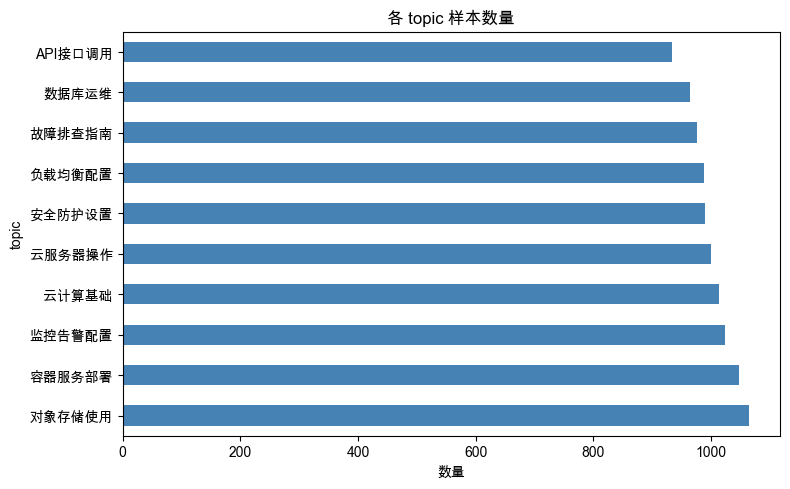

In [9]:
# === Cell 2: topic 分布 ===
# 看看每个领域有多少条数据，是否均衡
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac
plt.rcParams['axes.unicode_minus'] = False

topic_counts = df['topic'].value_counts()
print(topic_counts)

topic_counts.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('各 topic 样本数量')
plt.xlabel('数量')
plt.tight_layout()
plt.savefig('logs/topic_distribution.png', dpi=120)
plt.show()

        len_zh   len_ja   len_id
count  10000.0  10000.0  10000.0
mean      29.1     44.8     88.6
std        2.7      4.7     11.4
min       24.0     34.0     60.0
25%       27.0     42.0     83.0
50%       29.0     44.0     89.0
75%       31.0     48.0     95.0
max       39.0     58.0    124.0


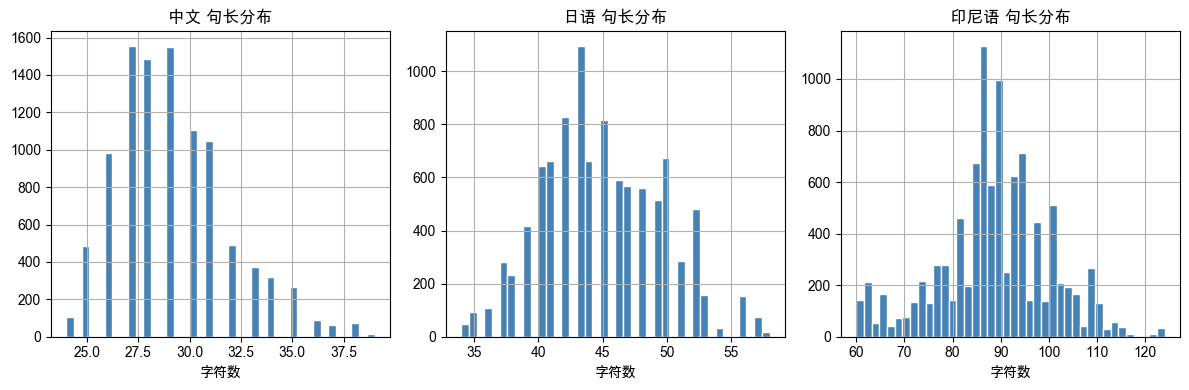

In [8]:
# === Cell 3: 句长分布 ===
# 看三种语言的句子长度，判断有没有异常短/长的样本
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac
plt.rcParams['axes.unicode_minus'] = False

df['len_zh'] = df['chinese'].str.len()
df['len_ja'] = df['japanese'].str.len()
df['len_id'] = df['indonesian'].str.len()

print(df[['len_zh', 'len_ja', 'len_id']].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, lang in zip(axes, ['len_zh', 'len_ja', 'len_id'], ['中文', '日语', '印尼语']):
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{lang} 句长分布')
    ax.set_xlabel('字符数')
plt.tight_layout()
plt.savefig('logs/sentence_length.png', dpi=120)
plt.show()

In [4]:
# === Cell 4: 混语检测 ===
# 核心问题：日语/印尼语里有多少中文字符没被翻译？
# 用正则检测 CJK 字符（\u4e00-\u9fff）在非中文列里出现的比例

def chinese_char_ratio(text):
    """计算文本中中文字符占比"""
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    zh_chars = re.findall(r'[\u4e00-\u9fff]', text)
    return len(zh_chars) / len(text)

df['zh_ratio_in_ja'] = df['japanese'].apply(chinese_char_ratio)
df['zh_ratio_in_id'] = df['indonesian'].apply(chinese_char_ratio)

# 设定阈值：中文占比 > 5% 视为混语问题样本
threshold = 0.05
ja_mixed = (df['zh_ratio_in_ja'] > threshold).sum()
id_mixed = (df['zh_ratio_in_id'] > threshold).sum()

print(f'日语中混语样本数: {ja_mixed} / {len(df)}  ({ja_mixed/len(df)*100:.1f}%)')
print(f'印尼语中混语样本数: {id_mixed} / {len(df)}  ({id_mixed/len(df)*100:.1f}%)')
print()
print('日语混语最严重的5条:')
df.nlargest(5, 'zh_ratio_in_ja')[['topic', 'chinese', 'japanese', 'zh_ratio_in_ja']]

日语中混语样本数: 10000 / 10000  (100.0%)
印尼语中混语样本数: 10000 / 10000  (100.0%)

日语混语最严重的5条:


,topic,chinese,japanese,zh_ratio_in_ja
249,对象存储使用,排查存储类型相关故障时，应优先检查对象存储使用和批量处理。,存储类型関連の障害を調査する場合、对象存储使用と批量处理を優先的に確認すべきです。,0.658537
362,对象存储使用,排查生命周期相关故障时，应优先检查对象存储使用和资源调度。,生命周期関連の障害を調査する場合、对象存储使用と资源调度を優先的に確認すべきです。,0.658537
426,对象存储使用,排查存储类型相关故障时，应优先检查对象存储使用和批量处理。,存储类型関連の障害を調査する場合、对象存储使用と批量处理を優先的に確認すべきです。,0.658537
435,容器服务部署,排查容器网络相关故障时，应优先检查容器服务部署和故障恢复。,容器网络関連の障害を調査する場合、容器服务部署と故障恢复を優先的に確認すべきです。,0.658537
544,对象存储使用,排查存储类型相关故障时，应优先检查对象存储使用和性能监控。,存储类型関連の障害を調査する場合、对象存储使用と性能监控を優先的に確認すべきです。,0.658537


In [ ]:
# === Cell 5: 重复样本检测 ===

# 完全重复（三列都一样）
exact_dupes = df.duplicated(subset=['chinese', 'japanese', 'indonesian']).sum()
print(f'完全重复行数（将被删除）: {exact_dupes}')
print(f'去重后剩余: {len(df) - exact_dupes}')

# 真正重复的例子
dup_mask = df.duplicated(subset=['chinese', 'japanese', 'indonesian'], keep=False)
dup_df = df[dup_mask].sort_values('chinese')

print('\n重复样本示例（同一句子出现多次）:')
# 找一个实际重复的中文句子
example_sentence = dup_df['chinese'].value_counts().index[0]
print(f'这句话出现了 {dup_df["chinese"].value_counts().iloc[0]} 次:')
print(example_sentence)

完全重复行数（将被删除）: 5509
去重后剩余: 4491

重复样本示例（同一句子出现多次）:
这句话出现了 8 次:
配置安全组时，需要注意云服务器操作和批量处理的兼容性。


In [ ]:
# === Cell 6: 缺失值检查 ===
print('缺失值统计:')
print(df.isnull().sum())
print()

# 空字符串（不是 NaN，但也是问题）
for col in ['chinese', 'japanese', 'indonesian']:
    empty = (df[col].str.strip() == '').sum()
    print(f'{col} 空字符串: {empty}')

缺失值统计:
topic             0
chinese           0
japanese          0
indonesian        0
len_zh            0
len_ja            0
len_id            0
zh_ratio_in_ja    0
zh_ratio_in_id    0
dtype: int64

chinese 空字符串: 0
japanese 空字符串: 0
indonesian 空字符串: 0


In [ ]:
# === Cell 7: 数据质量汇总报告 ===
print('=' * 40)
print('数据质量汇总')
print('=' * 40)
print(f'总样本数:        {len(df)}')
print(f'Topic 种类:      {df["topic"].nunique()}')
print(f'完全重复行:      {exact_dupes}')
print(f'日语混语样本:    {ja_mixed} ({ja_mixed/len(df)*100:.1f}%)')
print(f'印尼语混语样本:  {id_mixed} ({id_mixed/len(df)*100:.1f}%)')
print(f'缺失值:          {df.isnull().sum().sum()}')
print('=' * 40)
print('\n结论：主要问题是混语，下一步进入 preprocess.py 处理')

数据质量汇总
总样本数:        10000
Topic 种类:      10
完全重复行:      5509
日语混语样本:    10000 (100.0%)
印尼语混语样本:  10000 (100.0%)
缺失值:          0

结论：主要问题是混语，下一步进入 preprocess.py 处理


In [ ]:
# 先看这句话在哪些 topic 下出现
mask = df['chinese'] == '配置安全组时，需要注意云服务器操作和批量处理的兼容性。'
print(df[mask][['topic', 'chinese']].to_string())

#结论：因为句子和topic完全重复，直接 drop_duplicates 是安全的，不会误删有效数据。

       topic                      chinese
1024  云服务器操作  配置安全组时，需要注意云服务器操作和批量处理的兼容性。
1940  云服务器操作  配置安全组时，需要注意云服务器操作和批量处理的兼容性。
2851  云服务器操作  配置安全组时，需要注意云服务器操作和批量处理的兼容性。
5182  云服务器操作  配置安全组时，需要注意云服务器操作和批量处理的兼容性。
7808  云服务器操作  配置安全组时，需要注意云服务器操作和批量处理的兼容性。
8144  云服务器操作  配置安全组时，需要注意云服务器操作和批量处理的兼容性。
9232  云服务器操作  配置安全组时，需要注意云服务器操作和批量处理的兼容性。
9332  云服务器操作  配置安全组时，需要注意云服务器操作和批量处理的兼容性。
